# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test10 core state evolution

Notebook equivalent of `tests/1_core/test10_core_state_evolution.py`. The original Python test module remains the source of truth; this notebook imports it and runs each `test_*` function in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original Python test module, and reloads it so changes in the source file are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing editable installation paths.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test10_core_state_evolution"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "1_core" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\1_core\test10_core_state_evolution.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes test figures and any generated artifacts under `OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots are defined with the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\core\test10_core_state_evolution


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_state_evolution_through_toy_medium`

**What is checked:** State evolution through toy medium behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Python assert expression.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing or blank plots may indicate a changed plotting backend, an empty data grid, or an incorrect output path.


### Plot output for `test_state_evolution_through_toy_medium`

This test generates diagnostic plot files in `OUTPUT_DIR`:

- `state_evolution_probabilities.png`
- `state_evolution_norm.png`
- `toy_density_profile.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running test_state_evolution_through_toy_medium ...

STATE EVOLUTION THROUGH TOY MATTER MEDIUM
Initial state psi:
tensor([0.0000000000e+00+0.j, 1.0000000000e+00+0.j, 0.0000000000e+00+0.j], device='cuda:0', dtype=torch.complex128)
Initial probabilities:
tensor([0.0000000000e+00, 1.0000000000e+00, 0.0000000000e+00], device='cuda:0', dtype=torch.float64)
Initial norm = 1.000000000000e+00
Segment 0000
  x1 = 0.000000e+00, x2 = 5.000000e-03
  density = 1.396024e+00
  probabilities = [7.49470776e-06 9.99992334e-01 1.71393355e-07]
  norm = 1.000000000000e+00
Segment 0050
  x1 = 2.500000e-01, x2 = 2.550000e-01
  density = 1.155568e+00
  probabilities = [1.86218324e-02 9.80883777e-01 4.94390181e-04]
  norm = 1.000000000000e+00
Segment 0100
  x1 = 5.000000e-01, x2 = 5.050000e-01
  density = 1.093800e+00
  probabilities = [0.06578494 0.93250744 0.00170762]
  norm = 1.000000000000e+00
Segment 0150
  x1 = 7.500000e-01, x2 = 7.550000e-01
  density = 1.114968e+00
  probabilities = [0.12429576 0.87242

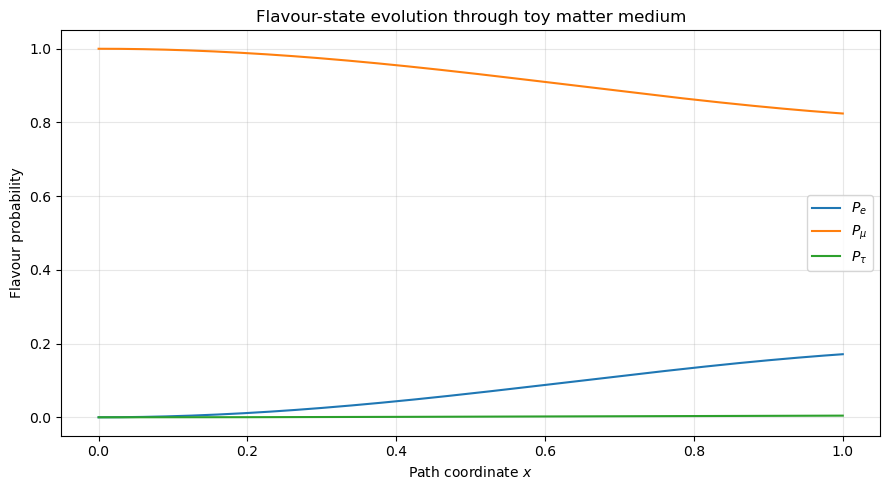

Saved plot: V:\output\test\core\test10_core_state_evolution\test_state_evolution_through_toy_medium_figure_002.png


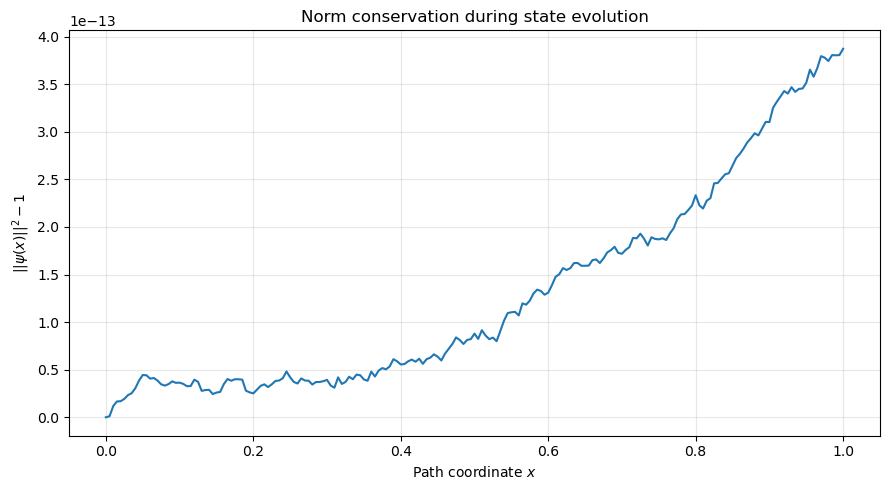

Saved plot: V:\output\test\core\test10_core_state_evolution\test_state_evolution_through_toy_medium_figure_003.png


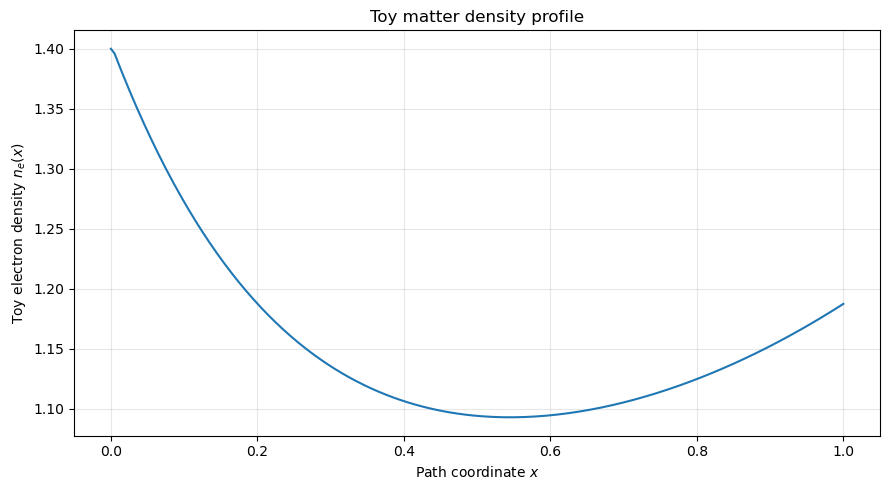

------------------------------------------------------------------------------------------
PASSED: test_state_evolution_through_toy_medium


In [4]:
run_notebook_test(TEST_MODULE.test_state_evolution_through_toy_medium)
